(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        7043 non-null   object
 1   gender            7043 non-null   object
 2   SeniorCitizen     7043 non-null   int64 
 3   Partner           7043 non-null   object
 4   Dependents        7043 non-null   object
 5   tenure            7043 non-null   int64 
 6   PhoneService      7043 non-null   object
 7   MultipleLines     7043 non-null   object
 8   InternetService   7043 non-null   object
 9   OnlineSecurity    7043 non-null   object
 10  OnlineBackup      7043 non-null   object
 11  DeviceProtection  7043 non-null   object
 12  TechSupport       7043 non-null   object
 13  StreamingTV       7043 non-null   object
 14  StreamingMovies   7043 non-null   object
 15  Contract          7043 non-null   object
 16  PaperlessBilling  7043 non-null   object
 17  Pay

/tmp/ipykernel_655/1743445034.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


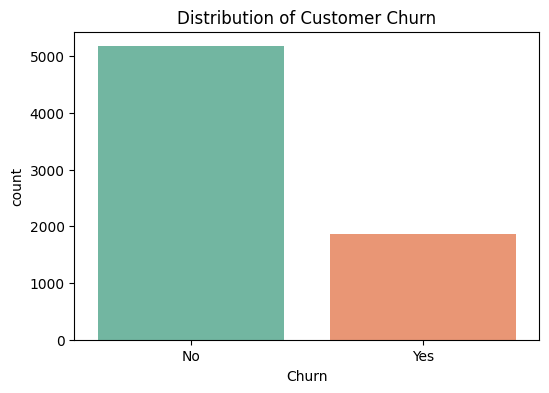

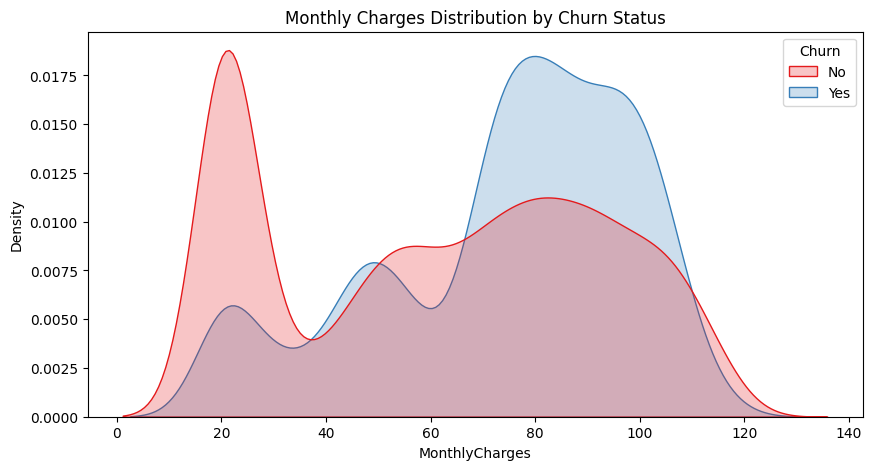

Encoded feature space shape: (7043, 30)
Accuracy Score: 0.7785663591199432

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.85      1035
           1       0.60      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409



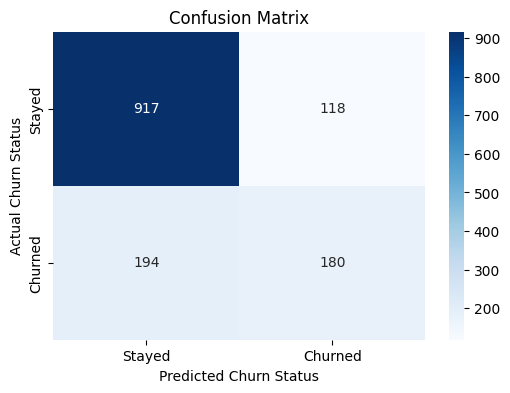

Finalizing your production pipeline...

[SUCCESS] Production pipeline successfully saved to disk as 'optimized_telco_churn_pipeline.pkl'!

          FINAL PRODUCTION PERFORMANCE REPORT          
Overall Model Accuracy: 76.01%

Detailed Segmentation Summary:
              precision    recall  f1-score   support

Retained (0)       0.88      0.78      0.83      1035
 Churned (1)       0.54      0.69      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.76      0.77      1409



In [22]:
import pandas as pd

df = pd.read_csv('telco_churn_clean.csv')

print(df.shape)
df.head()
df.info()
df.isnull().sum()
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Check target variable distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Distribution of Customer Churn')
plt.show()

# 2. Analyze Monthly Charges vs Churn
plt.figure(figsize=(10,5))
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, common_norm=False, palette='Set1')
plt.title('Monthly Charges Distribution by Churn Status')
plt.show()
# Drop CustomerID as it uniquely identifies individuals and won't help prediction
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

# Convert Churn target variable to binary (Yes=1, No=0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Separate features (X) and target (y)
X = df.drop(columns=['Churn'])
y = df['Churn']

# One-Hot Encode all categorical columns automatically
X_encoded = pd.get_dummies(X, drop_first=True)

print(f"Encoded feature space shape: {X_encoded.shape}")
from sklearn.model_selection import train_test_split

# Split into 80% train and 20% test (Corrected to test_size)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train the Random Forest model
model = RandomForestClassifier(random_state=42, n_estimators=100)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate baseline accuracy
print("Accuracy Score:", accuracy_score(y_test, y_pred))

# Display precision, recall, and f1-score
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Plot the Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'], yticklabels=['Stayed', 'Churned'])
plt.ylabel('Actual Churn Status')
plt.xlabel('Predicted Churn Status')
plt.title('Confusion Matrix')
plt.show()
import joblib
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

print("Finalizing your production pipeline...")

# 1. Construct the final optimized pipeline natively
final_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        class_weight='balanced',
        random_state=42
    ))
])

# 2. Fit on your entire training set
final_pipeline.fit(X_train, y_train)

# 3. Export the robust operational pipeline directly to disk
joblib.dump(final_pipeline, 'optimized_telco_churn_pipeline.pkl')
print("\n[SUCCESS] Production pipeline successfully saved to disk as 'optimized_telco_churn_pipeline.pkl'!")

# 4. Generate final evaluations
final_predictions = final_pipeline.predict(X_test)

print("\n" + "="*50)
print("          FINAL PRODUCTION PERFORMANCE REPORT          ")
print("==================================================")
print(f"Overall Model Accuracy: {accuracy_score(y_test, final_predictions):.2%}")
print("\nDetailed Segmentation Summary:")
print(classification_report(y_test, final_predictions, target_names=['Retained (0)', 'Churned (1)']))
print("="*50)


